In [1]:
# Phase 2 - Advanced Medicare Analytics Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Set professional chart style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'Arial'

print("=" * 50)
print("  Phase 2 - Advanced Medicare Analytics")
print("=" * 50)
print(f"  Started: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 50)
print("✅ All libraries loaded!")

  Phase 2 - Advanced Medicare Analytics
  Started: 2026-06-30 22:42
✅ All libraries loaded!


In [2]:
# Load the clean data from Phase 1
df = pd.read_csv('../output/medicare_clean.csv')

print("✅ Clean data loaded successfully!")
print(f"📊 Dataset Shape: {df.shape}")
print(f"📝 Rows: {df.shape[0]:,}")
print(f"📋 Columns: {df.shape[1]}")

✅ Clean data loaded successfully!


📊 Dataset Shape: (100000, 15)
📝 Rows: 100,000
📋 Columns: 15


In [3]:
# Create a real SQLite database
db_path = '../output/medicare_analytics.db'

# Connect to database
conn = sqlite3.connect(db_path)

# Load dataframe into SQL database
df.to_sql('medicare_claims', conn, if_exists='replace', index=False)

print("✅ Database created successfully!")
print(f"📁 Location: {db_path}")

# Verify it worked
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM medicare_claims")
count = cursor.fetchone()[0]
print(f"📊 Total records in database: {count:,}")

✅ Database created successfully!
📁 Location: ../output/medicare_analytics.db
📊 Total records in database: 100,000


In [4]:
# Advanced SQL Analysis
print("=" * 60)
print("  ADVANCED SQL ANALYSIS")
print("=" * 60)

# Query 1: Top 10 specialties
query1 = """
SELECT 
    Provider_Type,
    COUNT(DISTINCT NPI) as Total_Providers,
    SUM(Total_Medicare_Payment) as Total_Payment,
    AVG(Total_Medicare_Payment) as Avg_Payment_Per_Provider,
    SUM(Total_Beneficiaries) as Total_Patients,
    AVG(Avg_Risk_Score) as Avg_Risk_Score,
    ROUND(SUM(Total_Medicare_Payment) / SUM(Total_Beneficiaries), 2) as Payment_Per_Patient
FROM medicare_claims
GROUP BY Provider_Type
ORDER BY Total_Payment DESC
LIMIT 10
"""

df_specialty = pd.read_sql_query(query1, conn)
df_specialty['Total_Payment'] = df_specialty['Total_Payment'].apply(lambda x: f"${x:,.0f}")
df_specialty['Avg_Payment_Per_Provider'] = df_specialty['Avg_Payment_Per_Provider'].apply(lambda x: f"${x:,.0f}")
df_specialty['Payment_Per_Patient'] = df_specialty['Payment_Per_Patient'].apply(lambda x: f"${x:,.2f}")

print("\n📊 Query 1: Top 10 Specialties by Medicare Payment")
print("-" * 60)
print(df_specialty.to_string(index=False))

  ADVANCED SQL ANALYSIS



📊 Query 1: Top 10 Specialties by Medicare Payment
------------------------------------------------------------
             Provider_Type  Total_Providers Total_Payment Avg_Payment_Per_Provider  Total_Patients  Avg_Risk_Score Payment_Per_Patient
       Hematology-Oncology              684  $613,667,129                 $897,174          242759        2.041130           $2,527.89
         Internal Medicine             7448  $595,217,069                  $79,916         1929700        1.835308             $308.45
             Ophthalmology             1415  $585,825,863                 $414,011          875251        1.188605             $669.32
       Clinical Laboratory              296  $522,661,751               $1,765,749         2226353        1.391850             $234.76
Ambulatory Surgical Center              439  $445,355,578               $1,014,477          323223        1.162555           $1,377.86
        Nurse Practitioner            14332  $437,189,589                  $30

In [5]:
# Query 2: State Level KPI Analysis
query2 = """
SELECT 
    State,
    COUNT(DISTINCT NPI) as Total_Providers,
    COUNT(DISTINCT Provider_Type) as Specialty_Count,
    SUM(Total_Medicare_Payment) as Total_Payment,
    AVG(Total_Medicare_Payment) as Avg_Payment_Per_Provider,
    SUM(Total_Beneficiaries) as Total_Patients,
    AVG(Avg_Risk_Score) as Avg_Risk_Score,
    AVG(Avg_Age) as Avg_Patient_Age,
    ROUND(SUM(Total_Medicare_Payment) / SUM(Total_Beneficiaries), 2) as Payment_Per_Patient
FROM medicare_claims
GROUP BY State
ORDER BY Total_Payment DESC
LIMIT 15
"""

df_state = pd.read_sql_query(query2, conn)

print("\n📊 Query 2: Top 15 States — Full KPI Breakdown")
print("-" * 60)
df_state_display = df_state.copy()
df_state_display['Total_Payment'] = df_state_display['Total_Payment'].apply(lambda x: f"${x:,.0f}")
df_state_display['Avg_Risk_Score'] = df_state_display['Avg_Risk_Score'].apply(lambda x: f"{x:.2f}")
df_state_display['Avg_Patient_Age'] = df_state_display['Avg_Patient_Age'].apply(lambda x: f"{x:.1f}")
df_state_display['Payment_Per_Patient'] = df_state_display['Payment_Per_Patient'].apply(lambda x: f"${x:,.2f}")
print(df_state_display[['State', 'Total_Providers', 'Total_Payment', 
                          'Total_Patients', 'Avg_Risk_Score', 
                          'Avg_Patient_Age', 'Payment_Per_Patient']].to_string(index=False))


📊 Query 2: Top 15 States — Full KPI Breakdown
------------------------------------------------------------
State  Total_Providers  Total_Payment  Total_Patients Avg_Risk_Score Avg_Patient_Age Payment_Per_Patient
   CA             7949 $1,026,841,465         2504521           1.60            72.4             $410.00
   FL             6367   $897,587,635         2681024           1.71            73.7             $334.79
   TX             6591   $677,847,248         1979299           1.62            72.4             $342.47
   NY             7043   $624,944,335         2025688           1.65            72.6             $308.51
   NJ             2965   $443,094,831         1817222           1.57            73.7             $243.83
   PA             5047   $374,106,167         1427663           1.55            72.2             $262.04
   IL             3978   $324,524,975         1193417           1.61            72.9             $271.93
   AZ             1915   $270,078,514          60491

In [6]:
# Query 3: High Value Provider Analysis
query3 = """
WITH specialty_avg AS (
    SELECT 
        Provider_Type,
        AVG(Total_Medicare_Payment) as Specialty_Avg_Payment
    FROM medicare_claims
    GROUP BY Provider_Type
),
provider_analysis AS (
    SELECT 
        m.NPI,
        m.Last_Name,
        m.Provider_Type,
        m.State,
        m.Total_Medicare_Payment,
        m.Total_Beneficiaries,
        m.Avg_Risk_Score,
        s.Specialty_Avg_Payment,
        ROUND((m.Total_Medicare_Payment - s.Specialty_Avg_Payment) 
              / s.Specialty_Avg_Payment * 100, 2) as Pct_Above_Specialty_Avg
    FROM medicare_claims m
    JOIN specialty_avg s ON m.Provider_Type = s.Provider_Type
)
SELECT 
    NPI, Last_Name, Provider_Type, State,
    Total_Medicare_Payment, Total_Beneficiaries,
    Avg_Risk_Score, Pct_Above_Specialty_Avg
FROM provider_analysis
WHERE Pct_Above_Specialty_Avg > 200
ORDER BY Pct_Above_Specialty_Avg DESC
LIMIT 15
"""

df_outliers = pd.read_sql_query(query3, conn)
df_outliers['Total_Medicare_Payment'] = df_outliers['Total_Medicare_Payment'].apply(lambda x: f"${x:,.0f}")
df_outliers['Pct_Above_Specialty_Avg'] = df_outliers['Pct_Above_Specialty_Avg'].apply(lambda x: f"{x:.1f}%")

print("\n📊 Query 3: High Value Providers (200%+ Above Specialty Average)")
print("⚠️  These providers may warrant compliance review")
print("-" * 60)
print(df_outliers.to_string(index=False))


📊 Query 3: High Value Providers (200%+ Above Specialty Average)
⚠️  These providers may warrant compliance review
------------------------------------------------------------
       NPI                                          Last_Name                                  Provider_Type State Total_Medicare_Payment  Total_Beneficiaries  Avg_Risk_Score Pct_Above_Specialty_Avg
1063059673                          Mdp Products And Services                   Mass Immunizer Roster Biller    FL            $14,231,717                73760          1.4469                29304.5%
1073073532                                        Weatherford                             Nurse Practitioner    SC             $8,087,180                  710          1.2321                26411.5%
1023044906                                            Douglas                            Physician Assistant    SC             $5,676,666                  570          1.4657                22045.4%
1073029740                  

In [7]:
# Query 4: Payment Efficiency by Specialty
query4 = """
SELECT 
    Provider_Type,
    COUNT(DISTINCT NPI) as Provider_Count,
    SUM(Total_Beneficiaries) as Total_Patients,
    SUM(Total_Services) as Total_Services,
    SUM(Total_Medicare_Payment) as Total_Payment,
    ROUND(SUM(Total_Services) / COUNT(DISTINCT NPI), 0) as Avg_Services_Per_Provider,
    ROUND(SUM(Total_Beneficiaries) / SUM(Total_Medicare_Payment) * 1000, 2) as Patients_Per_1000_Dollars,
    AVG(Avg_Risk_Score) as Avg_Risk_Score
FROM medicare_claims
GROUP BY Provider_Type
HAVING COUNT(DISTINCT NPI) >= 100
ORDER BY Patients_Per_1000_Dollars DESC
LIMIT 12
"""

df_efficiency = pd.read_sql_query(query4, conn)

print("\n📊 Query 4: Most Efficient Specialties")
print("(Patients served per $1,000 Medicare spend)")
print("-" * 60)
df_eff_display = df_efficiency.copy()
df_eff_display['Total_Payment'] = df_eff_display['Total_Payment'].apply(lambda x: f"${x:,.0f}")
df_eff_display['Avg_Risk_Score'] = df_eff_display['Avg_Risk_Score'].apply(lambda x: f"{x:.2f}")
df_eff_display['Patients_Per_1000_Dollars'] = df_eff_display['Patients_Per_1000_Dollars'].apply(lambda x: f"{x:.2f}")
print(df_eff_display[['Provider_Type', 'Provider_Count', 
                        'Total_Patients', 'Total_Payment',
                        'Patients_Per_1000_Dollars', 
                        'Avg_Risk_Score']].to_string(index=False))


📊 Query 4: Most Efficient Specialties
(Patients served per $1,000 Medicare spend)
------------------------------------------------------------
                                 Provider_Type  Provider_Count  Total_Patients Total_Payment Patients_Per_1000_Dollars Avg_Risk_Score
                                   Audiologist             572           78640    $5,309,091                     14.81           1.11
                          Diagnostic Radiology            2547         4616322  $318,656,014                     14.49           1.73
                      Anesthesiology Assistant             226           26294    $2,551,506                     10.31           1.63
                               Centralized Flu             766          397124   $39,178,807                     10.14           0.98
                  Mass Immunizer Roster Biller            2458         1126659  $118,966,566                      9.47           0.98
                                     Pathology      

In [8]:
# Automated Data Quality Framework
from datetime import datetime

print("=" * 60)
print("  AUTOMATED DATA QUALITY REPORT")
print(f"  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)

# Check 1: Completeness
print("\n📋 CHECK 1: DATA COMPLETENESS")
print("-" * 40)
completeness = {}
for col in df.columns:
    missing = df[col].isnull().sum()
    pct = (missing / len(df)) * 100
    status = "✅ PASS" if pct == 0 else "⚠️ WARN" if pct < 5 else "❌ FAIL"
    completeness[col] = {'missing': missing, 'pct': pct, 'status': status}
    print(f"{status} | {col:<30} | Missing: {missing:,} ({pct:.2f}%)")

# Check 2: Validity
print("\n📋 CHECK 2: DATA VALIDITY")
print("-" * 40)
validity_checks = {
    'Negative Payments': (df['Total_Medicare_Payment'] < 0).sum(),
    'Zero Services': (df['Total_Services'] == 0).sum(),
    'Negative Beneficiaries': (df['Total_Beneficiaries'] < 0).sum(),
    'Invalid Age (< 65)': (df['Avg_Age'] < 65).sum(),
    'Invalid Age (> 100)': (df['Avg_Age'] > 100).sum(),
    'Negative Risk Score': (df['Avg_Risk_Score'] < 0).sum(),
    'Risk Score > 10': (df['Avg_Risk_Score'] > 10).sum(),
}
for check, count in validity_checks.items():
    status = "✅ PASS" if count == 0 else "❌ FAIL"
    print(f"{status} | {check:<35} | Issues: {count:,}")

# Check 3: Consistency
print("\n📋 CHECK 3: DATA CONSISTENCY")
print("-" * 40)
consistency_checks = {
    'Payment > Submitted Charges': (df['Total_Medicare_Payment'] > df['Total_Submitted_Charges']).sum(),
    'Allowed > Submitted Charges': (df['Total_Medicare_Allowed'] > df['Total_Submitted_Charges']).sum(),
    'Duplicate NPIs': df['NPI'].duplicated().sum(),
}
for check, count in consistency_checks.items():
    status = "✅ PASS" if count == 0 else "⚠️ WARN"
    print(f"{status} | {check:<35} | Count: {count:,}")

print("\n✅ DATA QUALITY REPORT COMPLETE")
print("=" * 60)

  AUTOMATED DATA QUALITY REPORT
  Generated: 2026-06-30 22:42:47

📋 CHECK 1: DATA COMPLETENESS
----------------------------------------
✅ PASS | NPI                            | Missing: 0 (0.00%)
✅ PASS | Last_Name                      | Missing: 0 (0.00%)
✅ PASS | First_Name                     | Missing: 0 (0.00%)
✅ PASS | Provider_Type                  | Missing: 0 (0.00%)
✅ PASS | State                          | Missing: 0 (0.00%)
✅ PASS | City                           | Missing: 0 (0.00%)
✅ PASS | Total_Beneficiaries            | Missing: 0 (0.00%)
✅ PASS | Total_Services                 | Missing: 0 (0.00%)


✅ PASS | Total_Submitted_Charges        | Missing: 0 (0.00%)
✅ PASS | Total_Medicare_Allowed         | Missing: 0 (0.00%)
✅ PASS | Total_Medicare_Payment         | Missing: 0 (0.00%)
✅ PASS | Avg_Age                        | Missing: 0 (0.00%)
✅ PASS | Female_Count                   | Missing: 0 (0.00%)
✅ PASS | Male_Count                     | Missing: 0 (0.00%)
✅ PASS | Avg_Risk_Score                 | Missing: 0 (0.00%)

📋 CHECK 2: DATA VALIDITY
----------------------------------------
✅ PASS | Negative Payments                   | Issues: 0
✅ PASS | Zero Services                       | Issues: 0
✅ PASS | Negative Beneficiaries              | Issues: 0
❌ FAIL | Invalid Age (< 65)                  | Issues: 6,187
✅ PASS | Invalid Age (> 100)                 | Issues: 0
✅ PASS | Negative Risk Score                 | Issues: 0
❌ FAIL | Risk Score > 10                     | Issues: 2

📋 CHECK 3: DATA CONSISTENCY
----------------------------------------
✅ PASS | Payment > Submitted Char

In [9]:
# Save Excel Quality Report
excel_path = '../output/medicare_quality_report.xlsx'
writer = pd.ExcelWriter(excel_path, engine='openpyxl')

# Sheet 1: Completeness
completeness_df = pd.DataFrame([
    {'Column': col, 'Missing Count': v['missing'], 
     'Missing %': round(v['pct'], 2), 'Status': v['status']}
    for col, v in completeness.items()
])
completeness_df.to_excel(writer, sheet_name='Completeness', index=False)

# Sheet 2: Validity
validity_df = pd.DataFrame([
    {'Check': check, 'Issue Count': count, 
     'Status': '✅ PASS' if count == 0 else '❌ FAIL'}
    for check, count in validity_checks.items()
])
validity_df.to_excel(writer, sheet_name='Validity', index=False)

# Sheet 3: Specialty KPIs
df_specialty_raw = pd.read_sql_query(query1.replace("LIMIT 10", "LIMIT 20"), conn)
df_specialty_raw.to_excel(writer, sheet_name='Specialty KPIs', index=False)

# Sheet 4: State KPIs
df_state.to_excel(writer, sheet_name='State KPIs', index=False)

# Sheet 5: High Value Providers
df_outliers_raw = pd.read_sql_query(query3, conn)
df_outliers_raw.to_excel(writer, sheet_name='High Value Providers', index=False)

# Sheet 6: Efficiency Analysis
df_efficiency.to_excel(writer, sheet_name='Efficiency Analysis', index=False)

writer.close()
print("✅ Excel Report saved successfully!")
print(f"📁 Location: {excel_path}")
print("\n📊 Sheets created:")
print("   1. Completeness")
print("   2. Validity")
print("   3. Specialty KPIs")
print("   4. State KPIs")
print("   5. High Value Providers")
print("   6. Efficiency Analysis")

✅ Excel Report saved successfully!
📁 Location: ../output/medicare_quality_report.xlsx

📊 Sheets created:
   1. Completeness
   2. Validity
   3. Specialty KPIs
   4. State KPIs
   5. High Value Providers
   6. Efficiency Analysis


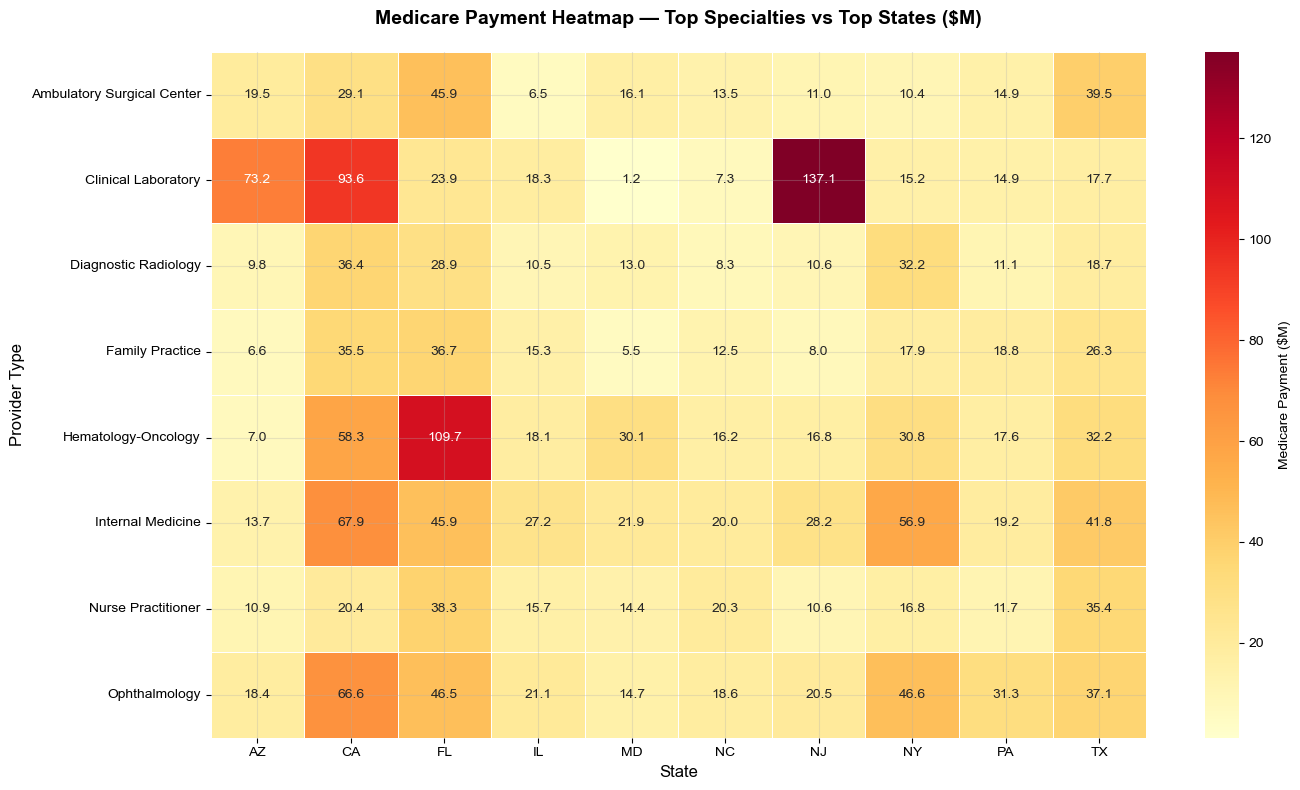

✅ Heatmap saved!


In [10]:
# Advanced Visualization 1 - Heatmap
top_states_list = df.groupby('State')['Total_Medicare_Payment']\
                    .sum().sort_values(ascending=False)\
                    .head(10).index.tolist()

top_specialties_list = df.groupby('Provider_Type')['Total_Medicare_Payment']\
                         .sum().sort_values(ascending=False)\
                         .head(8).index.tolist()

df_heatmap = df[
    (df['State'].isin(top_states_list)) & 
    (df['Provider_Type'].isin(top_specialties_list))
]

pivot = df_heatmap.pivot_table(
    values='Total_Medicare_Payment',
    index='Provider_Type',
    columns='State',
    aggfunc='sum',
    fill_value=0
) / 1_000_000

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Medicare Payment ($M)'}
)
plt.title('Medicare Payment Heatmap — Top Specialties vs Top States ($M)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('State', fontsize=12)
plt.ylabel('Provider Type', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../output/heatmap_specialty_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

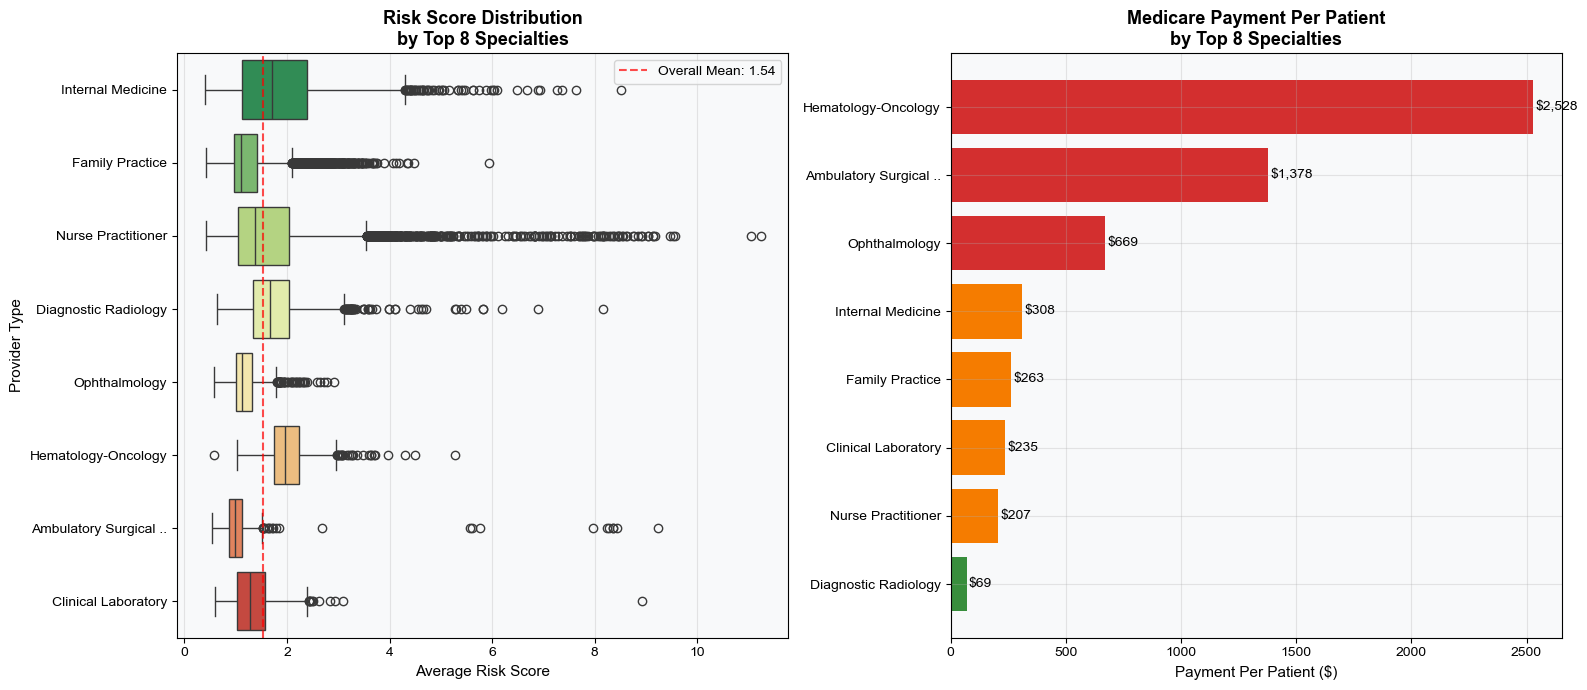

✅ Risk & Payment Analysis saved!


In [11]:
# Advanced Visualization 2 - Risk Score Box Plot + Payment Per Patient
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_10_spec = df.groupby('Provider_Type')['Total_Medicare_Payment']\
                .sum().sort_values(ascending=False)\
                .head(8).index.tolist()

df_box = df[df['Provider_Type'].isin(top_10_spec)].copy()
df_box['Provider_Short'] = df_box['Provider_Type'].apply(
    lambda x: x[:20] + '..' if len(x) > 20 else x
)

sns.boxplot(data=df_box, x='Avg_Risk_Score', y='Provider_Short',
            palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Risk Score Distribution\nby Top 8 Specialties',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Risk Score', fontsize=11)
axes[0].set_ylabel('Provider Type', fontsize=11)
axes[0].axvline(x=df['Avg_Risk_Score'].mean(), color='red',
                linestyle='--', alpha=0.7,
                label=f'Overall Mean: {df["Avg_Risk_Score"].mean():.2f}')
axes[0].legend()

df_specialty_calc = df.groupby('Provider_Type').agg(
    Total_Payment=('Total_Medicare_Payment', 'sum'),
    Total_Patients=('Total_Beneficiaries', 'sum')
).reset_index()
df_specialty_calc['Payment_Per_Patient'] = \
    df_specialty_calc['Total_Payment'] / df_specialty_calc['Total_Patients']
df_specialty_calc = df_specialty_calc[
    df_specialty_calc['Provider_Type'].isin(top_10_spec)
].sort_values('Payment_Per_Patient', ascending=True)
df_specialty_calc['Provider_Short'] = df_specialty_calc['Provider_Type'].apply(
    lambda x: x[:20] + '..' if len(x) > 20 else x
)

colors = ['#d32f2f' if x > 500 else '#f57c00' if x > 200 else '#388e3c'
          for x in df_specialty_calc['Payment_Per_Patient']]
axes[1].barh(df_specialty_calc['Provider_Short'],
             df_specialty_calc['Payment_Per_Patient'], color=colors)
axes[1].set_title('Medicare Payment Per Patient\nby Top 8 Specialties',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Payment Per Patient ($)', fontsize=11)
axes[1].set_ylabel('')
for i, v in enumerate(df_specialty_calc['Payment_Per_Patient']):
    axes[1].text(v + 10, i, f'${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../output/risk_payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Risk & Payment Analysis saved!")

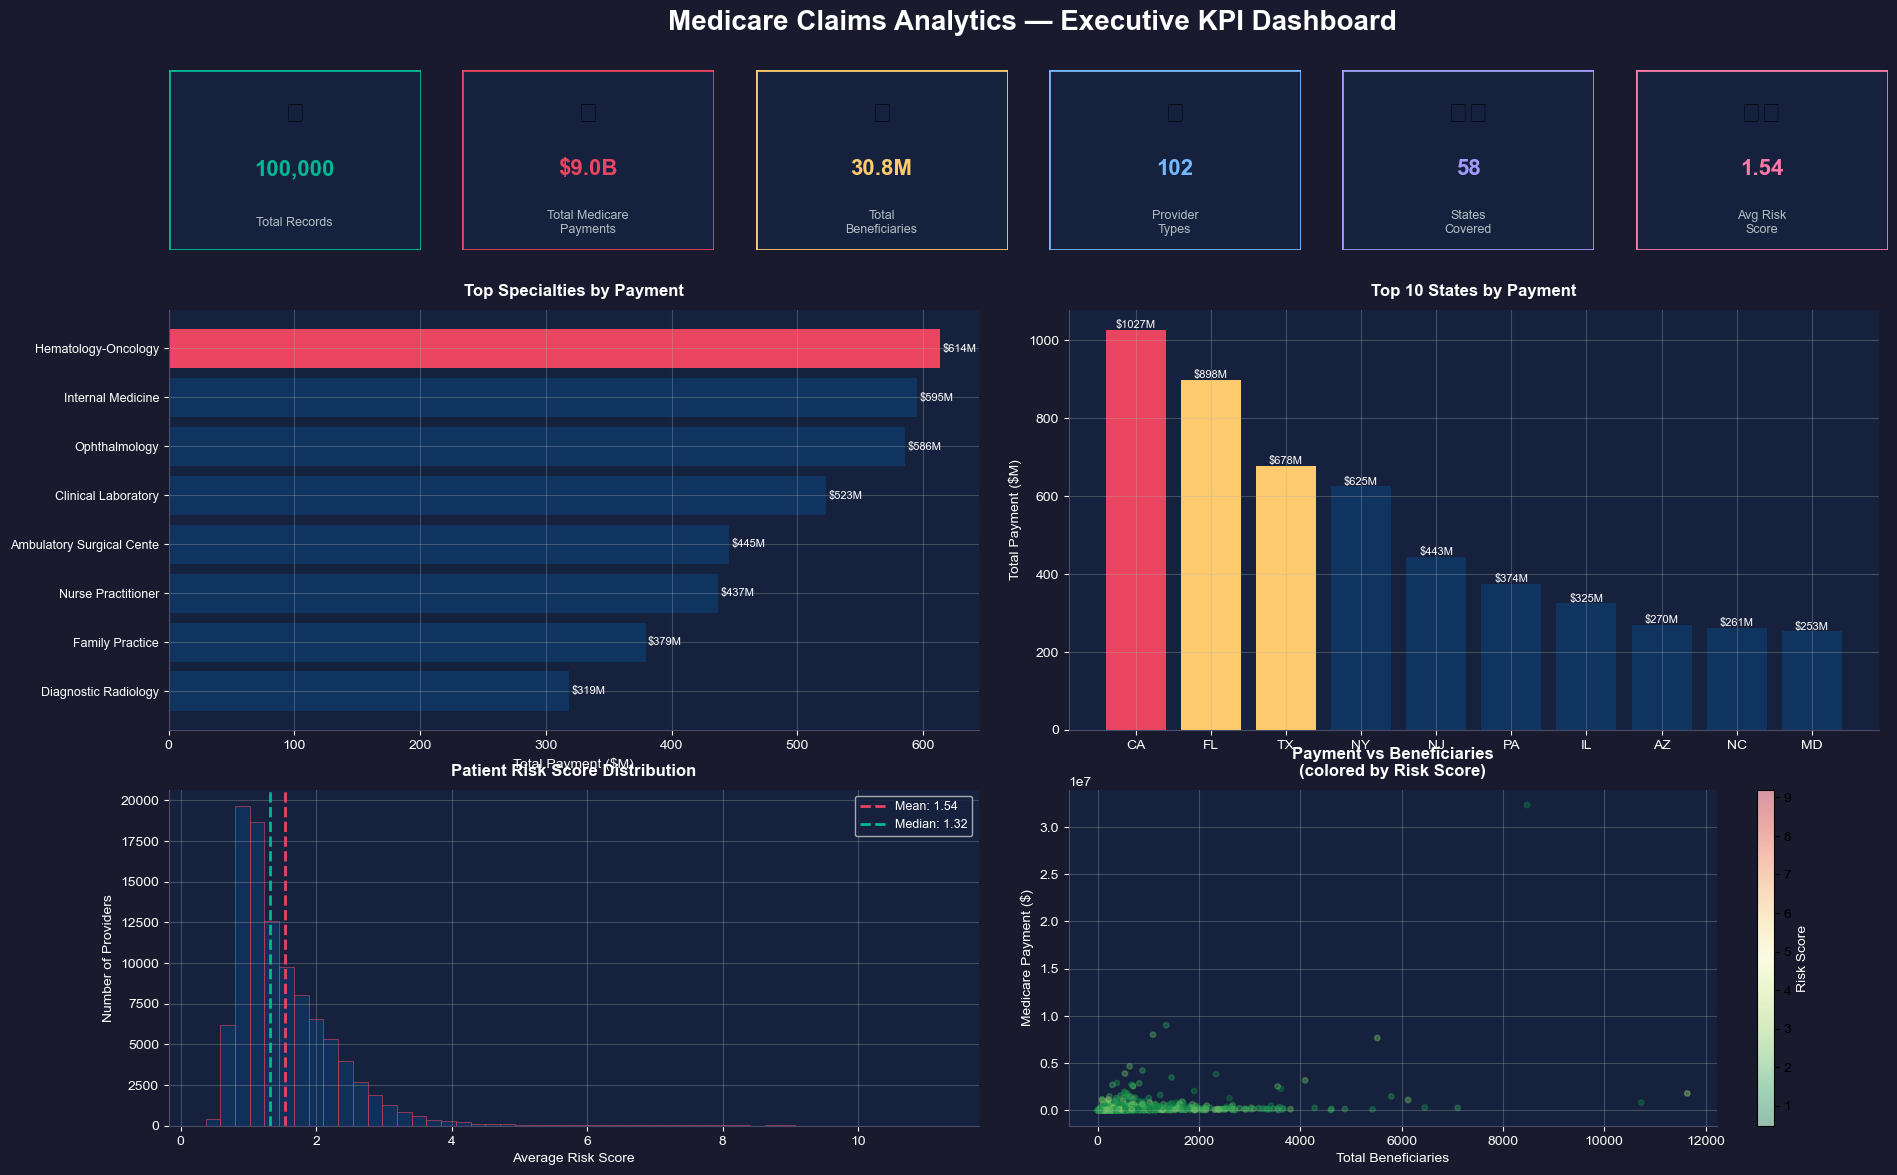

✅ Executive KPI Dashboard saved!


In [12]:
# Executive KPI Dashboard
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Medicare Claims Analytics — Executive KPI Dashboard',
             fontsize=20, fontweight='bold', color='white', y=0.98)

bg_color = '#1a1a2e'
card_color = '#16213e'
accent_blue = '#0f3460'
highlight = '#e94560'
text_color = 'white'
green = '#00b894'
orange = '#fdcb6e'

kpi_data = [
    ('Total Records', f'{len(df):,}', '📝', green),
    ('Total Medicare\nPayments', f'${df["Total_Medicare_Payment"].sum()/1e9:.1f}B', '💰', highlight),
    ('Total\nBeneficiaries', f'{df["Total_Beneficiaries"].sum()/1e6:.1f}M', '👥', orange),
    ('Provider\nTypes', f'{df["Provider_Type"].nunique()}', '🏥', '#74b9ff'),
    ('States\nCovered', f'{df["State"].nunique()}', '🗺️', '#a29bfe'),
    ('Avg Risk\nScore', f'{df["Avg_Risk_Score"].mean():.2f}', '⚕️', '#fd79a8'),
]

for i, (label, value, emoji, color) in enumerate(kpi_data):
    ax = fig.add_axes([0.02 + i*0.163, 0.78, 0.14, 0.15])
    ax.set_facecolor(card_color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, facecolor=card_color, edgecolor=color, linewidth=2))
    ax.text(0.5, 0.75, emoji, ha='center', va='center', fontsize=20)
    ax.text(0.5, 0.45, value, ha='center', va='center', fontsize=16, fontweight='bold', color=color)
    ax.text(0.5, 0.15, label, ha='center', va='center', fontsize=9, color='#b2bec3')

ax1 = fig.add_axes([0.02, 0.38, 0.45, 0.35])
ax1.set_facecolor(card_color)
top_spec = df.groupby('Provider_Type')['Total_Medicare_Payment']\
             .sum().sort_values(ascending=True).tail(8) / 1e6
colors_bar = [highlight if v == top_spec.max() else accent_blue for v in top_spec.values]
bars = ax1.barh(range(len(top_spec)), top_spec.values, color=colors_bar)
ax1.set_yticks(range(len(top_spec)))
ax1.set_yticklabels([t[:25] for t in top_spec.index], color=text_color, fontsize=9)
ax1.set_xlabel('Total Payment ($M)', color=text_color, fontsize=10)
ax1.set_title('Top Specialties by Payment', color=text_color, fontsize=12, fontweight='bold', pad=10)
ax1.tick_params(colors=text_color)
ax1.spines['bottom'].set_color('#4a4a6a')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4a4a6a')
for bar, val in zip(bars, top_spec.values):
    ax1.text(val + 2, bar.get_y() + bar.get_height()/2, f'${val:.0f}M', va='center', color=text_color, fontsize=8)

ax2 = fig.add_axes([0.52, 0.38, 0.45, 0.35])
ax2.set_facecolor(card_color)
top_st = df.groupby('State')['Total_Medicare_Payment']\
           .sum().sort_values(ascending=False).head(10) / 1e6
colors_states = [highlight if s == 'CA' else orange if s in ['FL', 'TX'] else accent_blue for s in top_st.index]
bars2 = ax2.bar(range(len(top_st)), top_st.values, color=colors_states)
ax2.set_xticks(range(len(top_st)))
ax2.set_xticklabels(top_st.index, color=text_color, fontsize=10)
ax2.set_ylabel('Total Payment ($M)', color=text_color, fontsize=10)
ax2.set_title('Top 10 States by Payment', color=text_color, fontsize=12, fontweight='bold', pad=10)
ax2.tick_params(colors=text_color)
ax2.spines['bottom'].set_color('#4a4a6a')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4a4a6a')
for bar, val in zip(bars2, top_st.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 5, f'${val:.0f}M', ha='center', color=text_color, fontsize=8)

ax3 = fig.add_axes([0.02, 0.05, 0.45, 0.28])
ax3.set_facecolor(card_color)
ax3.hist(df['Avg_Risk_Score'], bins=50, color=accent_blue, edgecolor=highlight, linewidth=0.5, alpha=0.8)
ax3.axvline(df['Avg_Risk_Score'].mean(), color=highlight, linestyle='--', linewidth=2,
            label=f'Mean: {df["Avg_Risk_Score"].mean():.2f}')
ax3.axvline(df['Avg_Risk_Score'].median(), color=green, linestyle='--', linewidth=2,
            label=f'Median: {df["Avg_Risk_Score"].median():.2f}')
ax3.set_xlabel('Average Risk Score', color=text_color, fontsize=10)
ax3.set_ylabel('Number of Providers', color=text_color, fontsize=10)
ax3.set_title('Patient Risk Score Distribution', color=text_color, fontsize=12, fontweight='bold', pad=10)
ax3.tick_params(colors=text_color)
ax3.spines['bottom'].set_color('#4a4a6a')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_color('#4a4a6a')
ax3.legend(facecolor=card_color, labelcolor=text_color, fontsize=9)

ax4 = fig.add_axes([0.52, 0.05, 0.45, 0.28])
ax4.set_facecolor(card_color)
df_sample = df.sample(n=5000, random_state=42)
scatter = ax4.scatter(df_sample['Total_Beneficiaries'], df_sample['Total_Medicare_Payment'],
                      c=df_sample['Avg_Risk_Score'], cmap='RdYlGn_r', alpha=0.4, s=15)
ax4.set_xlabel('Total Beneficiaries', color=text_color, fontsize=10)
ax4.set_ylabel('Medicare Payment ($)', color=text_color, fontsize=10)
ax4.set_title('Payment vs Beneficiaries\n(colored by Risk Score)', color=text_color, fontsize=12, fontweight='bold', pad=10)
ax4.tick_params(colors=text_color)
ax4.spines['bottom'].set_color('#4a4a6a')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_color('#4a4a6a')
plt.colorbar(scatter, ax=ax4, label='Risk Score').ax.yaxis.label.set_color(text_color)

plt.savefig('../output/executive_kpi_dashboard.png', dpi=150, bbox_inches='tight', facecolor=bg_color)
plt.show()
print("✅ Executive KPI Dashboard saved!")